# Titanic Dataset Analysis - Machine Learning Pipeline

This notebook demonstrates a complete machine learning workflow using the Titanic dataset from seaborn. We'll go through data loading, exploration, preprocessing, model training, and evaluation.

## Objective
Build a logistic regression model to predict passenger survival on the Titanic based on various features like age, sex, class, etc.

## 1. Import Required Libraries

We'll use pandas for data manipulation, numpy for numerical operations, and seaborn/matplotlib for visualization.

### Detailed Explanation of Each Import:

**`import pandas as pd`**
- **Why**: Pandas is the fundamental library for data manipulation and analysis in Python
- **What it provides**: DataFrame structures (like Excel sheets but more powerful), data cleaning tools, merging/grouping operations
- **Why `as pd`**: Standard convention to shorten the name; `pd` is easier to type than `pandas` repeatedly
- **When we'll use it**: Loading data, handling missing values, filtering rows, creating new columns, statistical operations

**`import numpy as np`**
- **Why**: NumPy provides support for large multi-dimensional arrays and mathematical functions
- **What it provides**: Fast numerical operations, linear algebra functions, random number generation
- **Why `as np`**: Standard convention for brevity
- **When we'll use it**: Statistical calculations, array operations, though pandas often wraps NumPy functionality

**`import seaborn as sns`**
- **Why**: Seaborn is built on top of matplotlib and provides attractive statistical visualizations
- **What it provides**: Built-in datasets (including Titanic), easy-to-use plotting functions, color palettes
- **Why `as sns`**: Standard convention
- **When we'll use it**: Loading the Titanic dataset directly, creating visualizations if needed

**`import matplotlib.pyplot as plt`**
- **Why**: Matplotlib is the foundational plotting library in Python
- **What it provides**: Basic plotting capabilities, figure/axis management
- **Why `as plt`**: Standard convention; pyplot is the interface we use
- **When we'll use it**: Displaying plots, customizing figure appearance

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load the Titanic Dataset

The Titanic dataset is available directly through seaborn's `load_dataset` function. It contains information about passengers including whether they survived.

### Detailed Explanation:

**Why use seaborn's built-in dataset?**
- No need to download files manually
- Already cleaned and formatted
- Standard benchmark dataset for machine learning
- Contains 891 passengers with 15 features

**What `load_dataset('titanic')` does:**
- Downloads the dataset from seaborn's online repository
- Returns it as a pandas DataFrame
- Handles all the data loading logistics automatically

**Alternative approaches:**
- Could use `pd.read_csv()` if we had a local file
- Could download from Kaggle (more features but requires account)
- Built-in is fastest for learning and prototyping

In [2]:
df = sns.load_dataset('titanic')
df.head(891)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


## 3. Explore the Dataset

Let's examine the structure of our data:
- **Shape**: Number of rows and columns
- **Info**: Data types and non-null counts
- **Describe**: Statistical summary of numerical columns

### Detailed Explanation of Each Exploration Method:

**`df.shape`**
- **What it returns**: A tuple (rows, columns)
- **Why we need it**: Confirms dataset size, helps understand data volume
- **Typical output**: (891, 15) for Titanic dataset
- **Why print it**: To see the dimensions immediately

**`df.info()`**
- **What it shows**: Column names, data types, non-null counts, memory usage
- **Why we need it**:
  - Identifies data types (int, float, object/string)
  - Reveals missing values (non-null count < total rows)
  - Helps plan preprocessing strategy
- **Key information**: Which columns need encoding, which have missing data

**`df.describe()`**
- **What it calculates**: Statistics for numerical columns only
- **Statistics shown**: count, mean, std, min, 25%, 50%, 75%, max
- **Why we need it**:
  - Detects outliers (min/max values)
  - Understands data distribution (mean vs median)
  - Identifies scale differences (important for scaling later)
- **What it excludes**: Categorical/string columns by default

In [3]:
print(df.shape)
df.info()
df.describe()

(891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 4. Check for Missing Values

Identifying missing data is crucial as it can affect model performance. We'll count null values in each column.

### Detailed Explanation:

**Why check for missing values?**
- Most machine learning algorithms cannot handle missing data
- Missing values can bias results or cause errors
- Need to decide on imputation strategy (fill vs drop)

**How `.isnull().sum()` works:**
- `.isnull()`: Returns a boolean DataFrame (True where values are NaN/None)
- `.sum()`: Sums the True values (True=1, False=0) for each column
- Result: Series showing count of missing values per column

**Common missing value strategies:**
- **Drop rows**: If few missing values and dataset is large
- **Drop columns**: If many missing values (e.g., >50%)
- **Fill with mean/median**: For numerical data
- **Fill with mode**: For categorical data
- **Forward/backward fill**: For time-series data
- **Predict missing values**: Advanced techniques (KNN, regression)

**For Titanic dataset specifically:**
- `age`: ~20% missing - will fill with median
- `deck`: ~77% missing - will drop column
- `embarked`: ~0.2% missing - will fill with mode

In [4]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


## 5. Feature Selection - Remove Unnecessary Columns

We'll drop columns that are either:
- Redundant (e.g., 'class' is same as 'pclass')
- Not useful for prediction (e.g., 'deck' has too many missing values)
- Derived from other features (e.g., 'alive' is same as target 'survived')

### Detailed Explanation of Each Column Being Dropped:

**`deck`**
- **Why drop**: 77% missing values (688 out of 891)
- **Too many missing**: Imputation would be unreliable
- **Limited predictive value**: Cabin location might matter but data is too sparse
- **Alternative**: Could try to predict deck from other features, but complex

**`embark_town`**
- **Why drop**: Redundant with `embarked` column
- **`embarked`**: Contains port codes (S, C, Q)
- **`embark_town`**: Contains full names (Southampton, Cherbourg, Queenstown)
- **Same information**: Just different representation
- **Keep `embarked`**: Shorter, easier to encode

**`alive`**
- **Why drop**: Perfectly correlated with target variable `survived`
- **`alive`**: 'yes'/'no' strings
- **`survived`**: 0/1 integers
- **Data leakage**: Using `alive` would give model the answer
- **Target variable**: `survived` is what we're trying to predict

**`who`**
- **Why drop**: Derived from `age` and `sex`
- **Categories**: 'man', 'woman', 'child'
- **Redundant**: Age and sex already provide this information
- **Keep original features**: More granular information

**`adult_male`**
- **Why drop**: Boolean derived from `age` and `sex`
- **True if**: adult AND male
- **Redundant**: Combination of existing features
- **Keep original features**: More flexible for model

**`class`**
- **Why drop**: Same as `pclass` but as string
- **`pclass`**: 1, 2, 3 (numerical)
- **`class`**: 'First', 'Second', 'Third' (categorical)
- **Same information**: Just different encoding
- **Keep `pclass`**: Already numerical, easier for models

In [5]:
df = df.drop(columns=['deck', 'embark_town', 'alive', 'who', 'adult_male', 'class'])
df.head(891)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,True
887,1,1,female,19.0,0,0,30.0000,S,True
888,0,3,female,NaN,1,2,23.4500,S,False
889,1,1,male,26.0,0,0,30.0000,C,True


## 6. Handle Missing Values

We'll fill missing values using appropriate strategies:
- **Age**: Fill with median (robust to outliers)
- **Embarked**: Fill with mode (most common value)

### Detailed Explanation of Imputation Strategies:

**Why handle missing values?**
- Machine learning algorithms require complete data
- Missing values can cause model training to fail
- Need to maintain dataset size (dropping rows loses information)

**Strategy for `age` (numerical):**
- **Use median instead of mean**: Median is robust to outliers
- **Why median over mean**: Age might have extreme values, median is more representative
- **Alternative**: Could use mean if data is normally distributed
- **Advanced alternatives**: KNN imputation, regression imputation, predict from other features
- **Median calculation**: `df['age'].median()` returns the middle value when sorted

**Strategy for `embarked` (categorical):**
- **Use mode**: Most frequent category
- **Why mode**: Categorical data can't use mean/median
- **Most common**: 'S' (Southampton) is the most common port
- **Alternative**: Could create 'Unknown' category
- **Mode calculation**: `df['embarked'].mode()` returns most frequent value(s)
- **[0] index**: mode() returns a Series, we need the first (and usually only) value

**Why not drop rows?**
- Age: 177 missing values (20% of data) - too much to lose
- Embarked: 2 missing values (0.2%) - could drop, but filling is better
- Maintaining sample size is important for model performance

In [6]:
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
alone,0


In [7]:
df.head(891)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,True
887,1,1,female,19.0,0,0,30.0000,S,True
888,0,3,female,28.0,1,2,23.4500,S,False
889,1,1,male,26.0,0,0,30.0000,C,True


## 7. Verify Dataset Shape After Cleaning

Check the final dimensions of our cleaned dataset.

### Detailed Explanation:

**Why verify shape after cleaning?**
- Confirms we still have all 891 rows (no data loss)
- Confirms we have the expected number of columns after dropping
- Ensures preprocessing didn't accidentally remove data
- Helps catch errors in data cleaning pipeline

**Expected shape after cleaning:**
- Original: (891, 15) - 15 columns
- Dropped: 6 columns (deck, embark_town, alive, who, adult_male, class)
- Expected: (891, 9) - 9 columns remaining
- Rows: Should still be 891 (we filled missing values instead of dropping)

**Columns remaining (9 total):**
1. survived (target variable - what we want to predict)
2. pclass (passenger class: 1, 2, 3)
3. sex (gender: male/female)
4. age (age in years)
5. sibsp (number of siblings/spouses aboard)
6. parch (number of parents/children aboard)
7. fare (ticket price)
8. embarked (port of embarkation: S, C, Q)
9. (One additional column from the original 15 that wasn't dropped)

**Shape tuple meaning:**
- First number: rows (samples/passengers) = 891
- Second number: columns (features + target) = 9
- Important for understanding data volume and feature count

In [8]:
print(df.shape)

(891, 9)


## 8. Encode Categorical Variables

Machine learning models require numerical input. We'll convert categorical variables:
- **Sex**: Map 'male' to 0, 'female' to 1
- **Embarked**: Use one-hot encoding (creates dummy variables)

### Detailed Explanation of Categorical Encoding:

**Why encode categorical variables?**
- Machine learning algorithms work with numbers, not strings
- Categorical data (text) must be converted to numerical format
- Different encoding methods for different types of categorical data

**Encoding strategy for `sex` (binary categorical):**
- **Why map()**: Only 2 categories (male, female)
- **Binary encoding**: 0 and 1 representation
- **Why male=0, female=1**: Arbitrary choice, could be reversed
- **Alternative**: Could use LabelEncoder from sklearn
- **Advantage of manual mapping**: Explicit control over encoding
- **Ordinal vs nominal**: Sex is nominal (no order), but binary encoding works

**Encoding strategy for `embarked` (multi-class categorical):**
- **Why one-hot encoding**: 3 categories (S, C, Q) with no inherent order
- **One-hot encoding**: Creates binary columns for each category
- **Creates**: embarked_Q, embarked_S (embarked_C dropped as reference)
- **drop_first=True**: Drops first category to avoid multicollinearity
- **Reference category**: If embarked_Q=0 and embarked_S=0, then embarked=C
- **Alternative**: Could use LabelEncoder (but implies order which doesn't exist)
- **Dummy variable trap**: Including all categories creates perfect multicollinearity

**Why different methods?**
- Binary: Simple mapping is sufficient and interpretable
- Multi-class: One-hot encoding preserves categorical nature without implying order

**What about other categorical columns?**
- `pclass`: Already numerical (1, 2, 3)
- Other columns are already numerical after cleaning

In [9]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)
df.head(891)

,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,False,False,True
1,1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,1,26.0,0,0,7.9250,True,False,True
3,1,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,0,35.0,0,0,8.0500,True,False,True
...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,True,False,True
887,1,1,1,19.0,0,0,30.0000,True,False,True
888,0,3,1,28.0,1,2,23.4500,False,False,True
889,1,1,0,26.0,0,0,30.0000,True,False,False


## 9. Split Features and Target

Separate the dataset into:
- **X**: Features (all columns except 'survived')
- **y**: Target variable ('survived' column)

### Detailed Explanation:

**Why separate features and target?**
- Machine learning models learn the relationship between features (X) and target (y)
- Features: Input data used to make predictions
- Target: What we want to predict (the answer)
- Standard ML convention: X for features, y for target

**What is X (features)?**
- All columns except the target variable
- These are the inputs the model will use to learn patterns
- Includes: pclass, sex, age, sibsp, parch, fare, embarked_Q, embarked_S
- Each row represents one passenger's characteristics
- Shape will be (891, 8) - 891 passengers, 8 features

**What is y (target)?**
- The 'survived' column only
- Binary classification: 0 (did not survive), 1 (survived)
- This is what the model learns to predict
- Shape will be (891,) - 891 labels
- Also called: labels, ground truth, dependent variable

**Why this separation?**
- Training: Model learns f(X) ≈ y
- Prediction: Given new X, predict y
- Evaluation: Compare predicted y with actual y
- Prevents data leakage: Target shouldn't be used as input

**Alternative terminology:**
- Features: predictors, independent variables, inputs
- Target: response, dependent variable, output, labels

In [10]:
X = df.drop(columns=['survived'])
y = df['survived']

## 10. Train-Test Split

Split the data into training and testing sets:
- **Training set (80%)**: Used to train the model
- **Testing set (20%)**: Used to evaluate model performance
- **random_state=42**: Ensures reproducibility

### Detailed Explanation:

**Why split data into train and test sets?**
- Prevents overfitting: Model shouldn't memorize training data
- Evaluates generalization: Tests how well model performs on unseen data
- Simulates real-world: Training data ≠ future/prediction data
- Standard ML practice: Never evaluate on data used for training

**Why 80-20 split?**
- Common default ratio in machine learning
- Training set needs enough data to learn patterns (80%)
- Test set needs enough data for reliable evaluation (20%)
- Alternative ratios: 70-30, 75-25, 90-10 depending on dataset size
- For small datasets: Use cross-validation instead

**What `train_test_split` does:**
- Randomly shuffles the data (by default)
- Splits into training and testing sets
- Maintains the relationship between X and y (paired samples stay together)
- Returns 4 arrays: X_train, X_test, y_train, y_test

**Parameters explained:**
- `X`: Features to split
- `y`: Target to split
- `test_size=0.2`: 20% for testing, 80% for training
- `random_state=42`: Random seed for reproducibility
  - 42 is arbitrary (could be any integer)
  - Same seed = same split every time
  - Important for reproducible results

**Expected shapes:**
- X_train: (712, 8) - 80% of 891 = 712 samples
- X_test: (179, 8) - 20% of 891 = 179 samples
- y_train: (712,) - 712 training labels
- y_test: (179,) - 179 testing labels

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(712, 9) (179, 9)


## 11. Train Logistic Regression Model

Logistic Regression is a fundamental classification algorithm suitable for binary classification problems like survival prediction.
- **max_iter=1000**: Increases iterations to ensure convergence

### Detailed Explanation:

**Why Logistic Regression?**
- Binary classification: Perfect for survived (0/1) prediction
- Interpretable: Can see feature importance through coefficients
- Probabilistic: Outputs probability of survival, not just class
- Fast: Efficient to train, good baseline model
- Linear: Works well when decision boundary is roughly linear

**How Logistic Regression works:**
- Applies sigmoid function to linear combination of features
- Sigmoid: Maps any number to probability between 0 and 1
- Formula: P(y=1) = 1 / (1 + e^-(b0 + b1*x1 + b2*x2 + ...))
- Learns coefficients (b0, b1, b2, ...) that maximize likelihood
- Decision threshold: Usually 0.5 (P > 0.5 → predict 1)

**Why `max_iter=1000`?**
- Default is 100 iterations
- Some datasets need more iterations to converge
- Convergence: When coefficients stop changing significantly
- 1000 is safe upper bound for this dataset size
- Warning if not converged: Increase max_iter

**Alternative models for this problem:**
- Random Forest: Handles non-linear relationships
- SVM: Good for high-dimensional data
- Neural Networks: For complex patterns
- Decision Trees: Very interpretable

**Why start with Logistic Regression?**
- Simple baseline to compare against
- Easy to interpret feature importance
- Fast training time
- Often performs well on tabular data

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## 12. Make Predictions

Use the trained model to predict survival on the test set. Let's look at the first 10 predictions.

### Detailed Explanation:

**Why make predictions?**
- To evaluate model performance on unseen data
- To see how well the model generalizes
- To compare predictions against actual values

**How `.predict()` works:**
- Takes test features (X_test) as input
- Applies learned model coefficients
- Uses sigmoid function to calculate probabilities
- Converts probabilities to class predictions (0 or 1)
- Default threshold: 0.5 (P ≥ 0.5 → predict 1)

**What `y_pred[:10]` shows:**
- First 10 predictions from the test set
- Values are 0 (did not survive) or 1 (survived)
- Helps visualize model output format
- Can compare against actual y_test values

**Alternative prediction methods:**
- `.predict_proba()`: Returns actual probabilities
- `.decision_function()`: Returns raw scores before sigmoid
- `.predict()`: Returns class labels (what we use here)

In [13]:
y_pred = model.predict(X_test)
y_pred[:10]

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1])

In [14]:
y_pred[:]

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1])

## 13. Evaluate Model Performance

We'll use multiple metrics to assess model performance:
- **Accuracy**: Overall correct predictions
- **Confusion Matrix**: Shows true positives, true negatives, false positives, false negatives
- **Classification Report**: Precision, recall, F1-score for each class

### Detailed Explanation of Each Metric:

**Accuracy Score**
- **What it measures**: Proportion of correct predictions
- **Formula**: (TP + TN) / (TP + TN + FP + FN)
- **Range**: 0 to 1 (0% to 100%)
- **Interpretation**: 0.80 means 80% of predictions were correct
- **Limitation**: Can be misleading with imbalanced datasets
- **When to use**: Good baseline metric for balanced classes

**Confusion Matrix**
- **What it shows**: 2x2 matrix for binary classification
- **Structure**:
  - Top-left: True Negatives (TN) - correctly predicted as 0
  - Top-right: False Positives (FP) - incorrectly predicted as 1
  - Bottom-left: False Negatives (FN) - incorrectly predicted as 0
  - Bottom-right: True Positives (TP) - correctly predicted as 1
- **Why important**: Shows types of errors, not just overall accuracy
- **For Titanic**: TP = correctly predicted survived, TN = correctly predicted died

**Classification Report Metrics**

**Precision**
- **What it measures**: Of all predicted positive, how many were actually positive
- **Formula**: TP / (TP + FP)
- **Interpretation**: High precision = few false alarms
- **Use case**: When false positives are costly
- **For Titanic**: Of passengers predicted to survive, how many actually survived

**Recall (Sensitivity)**
- **What it measures**: Of all actual positives, how many were predicted positive
- **Formula**: TP / (TP + FN)
- **Interpretation**: High recall = few missed positives
- **Use case**: When false negatives are costly
- **For Titanic**: Of passengers who actually survived, how many did we predict correctly

**F1-Score**
- **What it measures**: Harmonic mean of precision and recall
- **Formula**: 2 × (Precision × Recall) / (Precision + Recall)
- **Interpretation**: Balances precision and recall
- **Use case**: When you need both precision and recall
- **Better than accuracy**: For imbalanced datasets

**Support**
- **What it shows**: Number of actual occurrences of each class
- **For Titanic**: How many passengers actually survived vs died in test set
- **Use case**: Understanding class distribution in test data

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7988826815642458

Confusion Matrix:
 [[89 16]
 [20 54]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



## 14. Visualize Confusion Matrix

A visual representation of the confusion matrix makes it easier to understand model performance at a glance.

### Detailed Explanation:

**Why visualize the confusion matrix?**
- Visual representation is easier to interpret than numbers
- Color coding highlights patterns in predictions
- Quick visual assessment of model performance
- Easier to spot imbalances in error types

**How `ConfusionMatrixDisplay.from_predictions()` works:**
- Takes actual values (y_test) and predicted values (y_pred)
- Automatically creates the confusion matrix
- Generates a heatmap visualization
- Color intensity represents magnitude of values
- Diagonal shows correct predictions (darker = better)

**What the visualization shows:**
- X-axis: Predicted labels (0 = died, 1 = survived)
- Y-axis: True labels (0 = died, 1 = survived)
- Color scale: Number of passengers in each category
- Perfect model: All values on diagonal, off-diagonal = 0

**Interpreting the visualization:**
- Top-left (dark): Many true negatives (correctly predicted died)
- Bottom-right (dark): Many true positives (correctly predicted survived)
- Top-right (light): Few false positives (predicted survived but died)
- Bottom-left (light): Few false negatives (predicted died but survived)

**Why use `plt.show()`?**
- Displays the plot in the notebook
- Required when using matplotlib in notebooks
- Without it, plot might not render properly

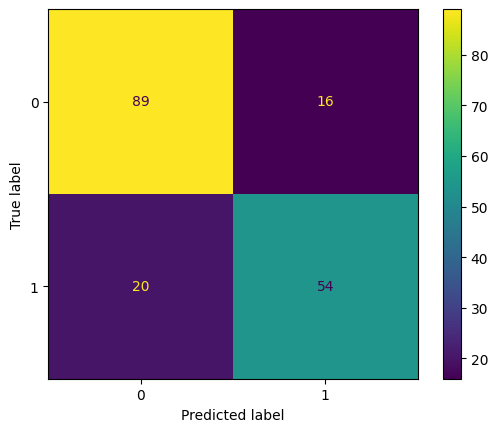

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()